In [201]:
import os
import subprocess
import geopandas as gpd
import xarray as xr
import rioxarray
import numpy as np
from shapely.geometry import box

# -----------------------------
# Helper functions
# -----------------------------

def get_range(start, end):
    startval = (int(start // 1e5) // 3) * 3
    endval = (int(end // 1e5) // 3) * 3
    return list(range(startval, endval + 1, 3))

def getxrange(ext):
    return get_range(ext[0], ext[2])

def getyrange(ext):
    return get_range(ext[1], ext[3])

# -----------------------------
# Paths
# -----------------------------
targetfolder = "/net/projects/forexd/WP1/Data/S1_Subsets/"
tcc_folder = "/net/projects/forexd/WP1/Data/CONUS/tcc/"
manual_base_folder = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/data/manual_planet_labels"

import geopandas as gpd
from pathlib import Path
# Load manual geometry
manual_wind_path = os.path.join(manual_base_folder, f"planet_labels/merged_wind_manual.shp")
manual_defoliators_path = os.path.join(manual_base_folder, f"planet_labels/merged_defoliators_manual.shp")
manual_bark_beetle_path = os.path.join(manual_base_folder, f"planet_labels/merged_bark_beetle_manual.shp")
manual_wind = gpd.read_file(manual_wind_path)
manual_defoliators = gpd.read_file(manual_defoliators_path)
manual_bark_beetle = gpd.read_file(manual_bark_beetle_path)

manual_wind_elem = manual_wind[manual_wind["IDX_D"] == "wind_2018_1879"]
manual_defoliators_elem = manual_defoliators[manual_defoliators["IDX_D"] == "defoliators_2021_1730"]
manual_bark_beetle_elem = manual_bark_beetle[manual_bark_beetle["IDX_D"] == "bark_beetle_2018_203"]

# -----------------------------
# Read shapefile
# -----------------------------

ids = gpd.read_file("/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/data/manual_planet_labels/planet_labels/IDS_polygons.shp")

# Reproject
ids = ids.to_crs(epsg=27705)
ids

,IDX_D,DCA_ID,IDS_Years,S1_Years,geometry
0,bark_beetle_2018_203,bark_beetle,"[2018, 2019, 2020]","[2016, 2017]","POLYGON ((9565202.163 2885035.78, 9565224.282 ..."
1,defoliators_2021_1730,defoliators,"[2020, 2021]","[2019, 2020]","MULTIPOLYGON (((8609421.536 2694740, 8609425.0..."
2,wind_2018_1879,wind,"[2018, 2019]","[2016, 2017, 2018, 2019, 2020]","POLYGON ((9452595.404 2629721.892, 9452693.694..."


In [130]:
# Filter the GeoDataFrame
bb = ids[ids["DCA_ID"] == "bark_beetle"]

# Find matching files
zarr_files = [
    os.path.join(targetfolder, f)
    for f in os.listdir(targetfolder)
    if f.endswith(".zarr") and "subset_bark_beetle" in f
]

print("Found files:")
for f in zarr_files:
    print(f)

datasets = []

for zarr_path in zarr_files:
    print(f"Opening {zarr_path}")
    ds = xr.open_zarr(zarr_path, consolidated=False)
    datasets.append(ds)

print(f"Loaded {len(datasets)} datasets")

Found files:
/net/projects/forexd/WP1/Data/S1_Subsets/EQUI7_NA020M_E093N027T3_rqatrend_VH_A_thresh_3.0_year_2017_subset_bark_beetle_2018_203.zarr
/net/projects/forexd/WP1/Data/S1_Subsets/EQUI7_NA020M_E093N027T3_rqatrend_VH_A_thresh_3.0_year_2016_subset_bark_beetle_2018_203.zarr
Opening /net/projects/forexd/WP1/Data/S1_Subsets/EQUI7_NA020M_E093N027T3_rqatrend_VH_A_thresh_3.0_year_2017_subset_bark_beetle_2018_203.zarr
Opening /net/projects/forexd/WP1/Data/S1_Subsets/EQUI7_NA020M_E093N027T3_rqatrend_VH_A_thresh_3.0_year_2016_subset_bark_beetle_2018_203.zarr
Loaded 2 datasets


In [162]:
import rioxarray
import logging
from pyproj import Transformer
import matplotlib.pyplot as plt

def apply_tcc_mask(dataset, tcc_raster_path, threshold):
    """
    Applies a Tree Canopy Cover (TCC) mask to the dataset based on the TCC raster file.
    Shows the TCC raster before applying threshold mask.
    """
    
    # --- Step 1: Load TCC raster ---
    tcc_data = rioxarray.open_rasterio(tcc_raster_path)
    #print("TCC raster loaded:", tcc_data)
    #print("TCC dims:", tcc_data.dims)

    # --- Step 2: Check CRS ---
    ds_crs = dataset.rio.crs
    tcc_crs = tcc_data.rio.crs
    #print(f"Dataset CRS: {ds_crs}, TCC CRS: {tcc_crs}")

    # --- Step 3: Dataset bounds ---
    x_min, x_max = float(dataset['X'].min()), float(dataset['X'].max())
    y_min, y_max = float(dataset['Y'].min()), float(dataset['Y'].max())
    #print(f"Dataset bounds: x=[{x_min},{x_max}], y=[{y_min},{y_max}]")

    # --- Step 4: Transform bounds to TCC CRS ---
    transformer = Transformer.from_crs(ds_crs, tcc_crs, always_xy=True)
    corners = [transformer.transform(x, y) for x, y in [
        (x_min, y_min), (x_max, y_max), (x_min, y_max), (x_max, y_min)
    ]]
    xs, ys = zip(*corners)
    x_min_tcc, x_max_tcc = min(xs), max(xs)
    y_min_tcc, y_max_tcc = min(ys), max(ys)
    #print(f"Transformed bounds in TCC CRS: x=[{x_min_tcc},{x_max_tcc}], y=[{y_min_tcc},{y_max_tcc}]")

    # --- Step 5: Subset TCC raster ---
    tcc_subset = tcc_data.sel(
        x=slice(x_min_tcc, x_max_tcc),
        y=slice(y_max_tcc, y_min_tcc)  # y reversed
    )
    # print("TCC subset dims:", tcc_subset.dims)
    # print("TCC subset values (min/max):", float(tcc_subset.min()), float(tcc_subset.max()))

    # --- Step 6: Reproject TCC to dataset grid ---
    tcc_reproj = tcc_subset.rio.reproject_match(dataset)
    # print("TCC reprojected dims:", tcc_reproj.dims)
    # print("TCC reprojected values (min/max):", float(tcc_reproj.min()), float(tcc_reproj.max()))

    # # --- Step 7: Normalize and plot TCC ---
    # #tcc_norm = tcc_reproj / 255.0
    # #print("Normalized TCC values (min/max):", float(tcc_norm.min()), float(tcc_norm.max()))

    # plt.figure(figsize=(6,6))
    # tcc_reproj.squeeze().plot.imshow(cmap="Greens")
    # plt.title("TCC reprojected raster")
    # plt.show()

    # --- Step 8: Apply threshold mask ---
    mask = tcc_reproj.squeeze() > threshold
    # Reindex to match da_thresh exactly
    mask = mask.rio.write_crs(dataset.rio.crs)
    mask = mask.reindex_like(dataset)
    mask_clean = mask.squeeze()  # entfernt 'band', 'spatial_ref'
    mask_clean = mask_clean.rename({'y': 'Y', 'x': 'X'})  # passt Dimensionen an da_thresh an
    masked_dataset = da_thresh.where(mask_clean, other=1)
    # Squeeze extra dimensions (e.g., 'band')
    #print("Mask summary:", mask.sum().values, "pixels above threshold")
    return masked_dataset


In [ ]:
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray
import os
import re
from pyproj import Transformer

# --- PARAMETERS ---
dca_id = "bark_beetle"
threshold_rqa = -1.28  # Example threshold
tcc_threshold = 0.35   # TCC threshold

# --- FIND ZARR FILE ---
zarr_files = [
    os.path.join(targetfolder, f)
    for f in os.listdir(targetfolder)
    if f.endswith(".zarr") and f"subset_{dca_id}" in f
]

if not zarr_files:
    raise FileNotFoundError(f"No Zarr files found for {dca_id}")

path = zarr_files[0]

# --- OPEN DATASET ---
da = xr.open_zarr(path, consolidated=False)["layer"]
print("Original DA dims:", da.dims)
print("Original CRS:", da.rio.crs)


# --- THRESHOLD THE DISTURBANCE ---
da_thresh = (da > threshold_rqa).astype(int)
print("Dims after thresholding:", da_thresh.dims)
# Threshold the disturbance

# Assign CRS to thresholded DataArray
da_thresh = da_thresh.rio.set_spatial_dims(x_dim="X", y_dim="Y", inplace=False)
da_thresh = da_thresh.rio.write_crs("EPSG:27705")


# --- PARSE YEAR AND TCC PATH ---
filename = os.path.basename(path)
match = re.search(r"_year_(\d{4})_", filename)
if match:
    year = int(match.group(1))
    tcc_year = year - 1
    tcc_path = os.path.join(
        tcc_folder,
        f'wp1_nlcd_tcc_conus_{tcc_year}_20m_EPSG_27705_cropped_normalized_region_08.tif'
    )

# --- APPLY TCC MASK ---
mask = apply_tcc_mask(da_thresh, tcc_path, threshold=tcc_threshold)


In [188]:
import geopandas as gpd
from shapely.geometry import shape
import rasterio.features
import numpy as np
from affine import Affine
import pandas as pd

def extract_polygons_within_buffer(da_final, buffer_gdf, filename, threshold):
    """
    Extract polygons from a masked DataArray, and keep only those intersecting a buffer.

    Parameters:
    - da_final (xarray.DataArray): masked disturbance array (thresholded & TCC masked)
    - buffer_gdf (GeoDataFrame): buffer zone (in same CRS as da_final)
    - filename (str): name of file for metadata
    - threshold (float): threshold value used

    Returns:
    - GeoDataFrame: polygons intersecting the buffer with metadata
    """

    # Step 1: Drop band dim if present
    if 'band' in da_final.dims:
        da = da_final.squeeze('band')
    else:
        da = da_final

    # Step 2: Build binary mask (values == 0)
    mask = (da == 0).astype(np.uint8)

    # Step 3: Affine transform
    x_res = float(da['X'][1] - da['X'][0])
    y_res = float(da['Y'][1] - da['Y'][0])
    transform = Affine.translation(float(da['X'][0]), float(da['Y'][0])) * Affine.scale(x_res, y_res)

    # Step 4: Extract polygons
    extracted_shapes = rasterio.features.shapes(mask.values, transform=transform)
    polygons = [shape(geom) for geom, val in extracted_shapes if val == 1]

    # Step 5: Create GeoDataFrame
    polygons_gdf = gpd.GeoDataFrame(geometry=polygons, crs=da_final.rio.crs)

    # Step 6: Filter polygons by buffer intersection
    if not buffer_gdf.empty:
        polygons_gdf = polygons_gdf[polygons_gdf.intersects(buffer_gdf.unary_union)]

    # Step 7: Add metadata
    year = int(filename.split('_year_')[-1].split('_')[0])
    polygons_gdf['S1_YEAR'] = year
    polygons_gdf['THRESHOLD'] = threshold
    polygons_gdf['FILENAME'] = filename

    return polygons_gdf.reset_index(drop=True)


Found 2 Zarr files for bark_beetle


/tmp/ipykernel_634006/61100033.py:45: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygons_gdf = polygons_gdf[polygons_gdf.intersects(buffer_gdf.unary_union)]
/tmp/ipykernel_634006/61100033.py:45: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygons_gdf = polygons_gdf[polygons_gdf.intersects(buffer_gdf.unary_union)]
/tmp/ipykernel_634006/61100033.py:45: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygons_gdf = polygons_gdf[polygons_gdf.intersects(buffer_gdf.unary_union)]
/tmp/ipykernel_634006/61100033.py:45: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygons_gdf = polygons_gdf[polygons_gdf.intersects(buffer_gdf.unary_union)]
/tmp/ipykernel_634006/61100033.py:45: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' metho

Using /net/projects/forexd/WP1/Data/S1_Subsets/EQUI7_NA020M_E093N027T3_rqatrend_VH_A_thresh_3.0_year_2017_subset_bark_beetle_2018_203.zarr for plots for bark_beetle
Found 5 Zarr files for wind


/tmp/ipykernel_634006/61100033.py:45: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygons_gdf = polygons_gdf[polygons_gdf.intersects(buffer_gdf.unary_union)]
/tmp/ipykernel_634006/61100033.py:45: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygons_gdf = polygons_gdf[polygons_gdf.intersects(buffer_gdf.unary_union)]
/tmp/ipykernel_634006/61100033.py:45: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygons_gdf = polygons_gdf[polygons_gdf.intersects(buffer_gdf.unary_union)]
/tmp/ipykernel_634006/61100033.py:45: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygons_gdf = polygons_gdf[polygons_gdf.intersects(buffer_gdf.unary_union)]
/tmp/ipykernel_634006/61100033.py:45: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' metho

Using /net/projects/forexd/WP1/Data/S1_Subsets/EQUI7_NA020M_E093N024T3_rqatrend_VH_A_thresh_3.0_year_2020_subset_wind_2018_1879.zarr for plots for wind
Found 2 Zarr files for defoliators


/tmp/ipykernel_634006/61100033.py:45: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygons_gdf = polygons_gdf[polygons_gdf.intersects(buffer_gdf.unary_union)]
/tmp/ipykernel_634006/61100033.py:45: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygons_gdf = polygons_gdf[polygons_gdf.intersects(buffer_gdf.unary_union)]
/tmp/ipykernel_634006/61100033.py:45: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygons_gdf = polygons_gdf[polygons_gdf.intersects(buffer_gdf.unary_union)]
/tmp/ipykernel_634006/61100033.py:45: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygons_gdf = polygons_gdf[polygons_gdf.intersects(buffer_gdf.unary_union)]
/tmp/ipykernel_634006/61100033.py:45: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' metho

Using /net/projects/forexd/WP1/Data/S1_Subsets/EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3.0_year_2019_subset_defoliators_2021_1730.zarr for plots for defoliators


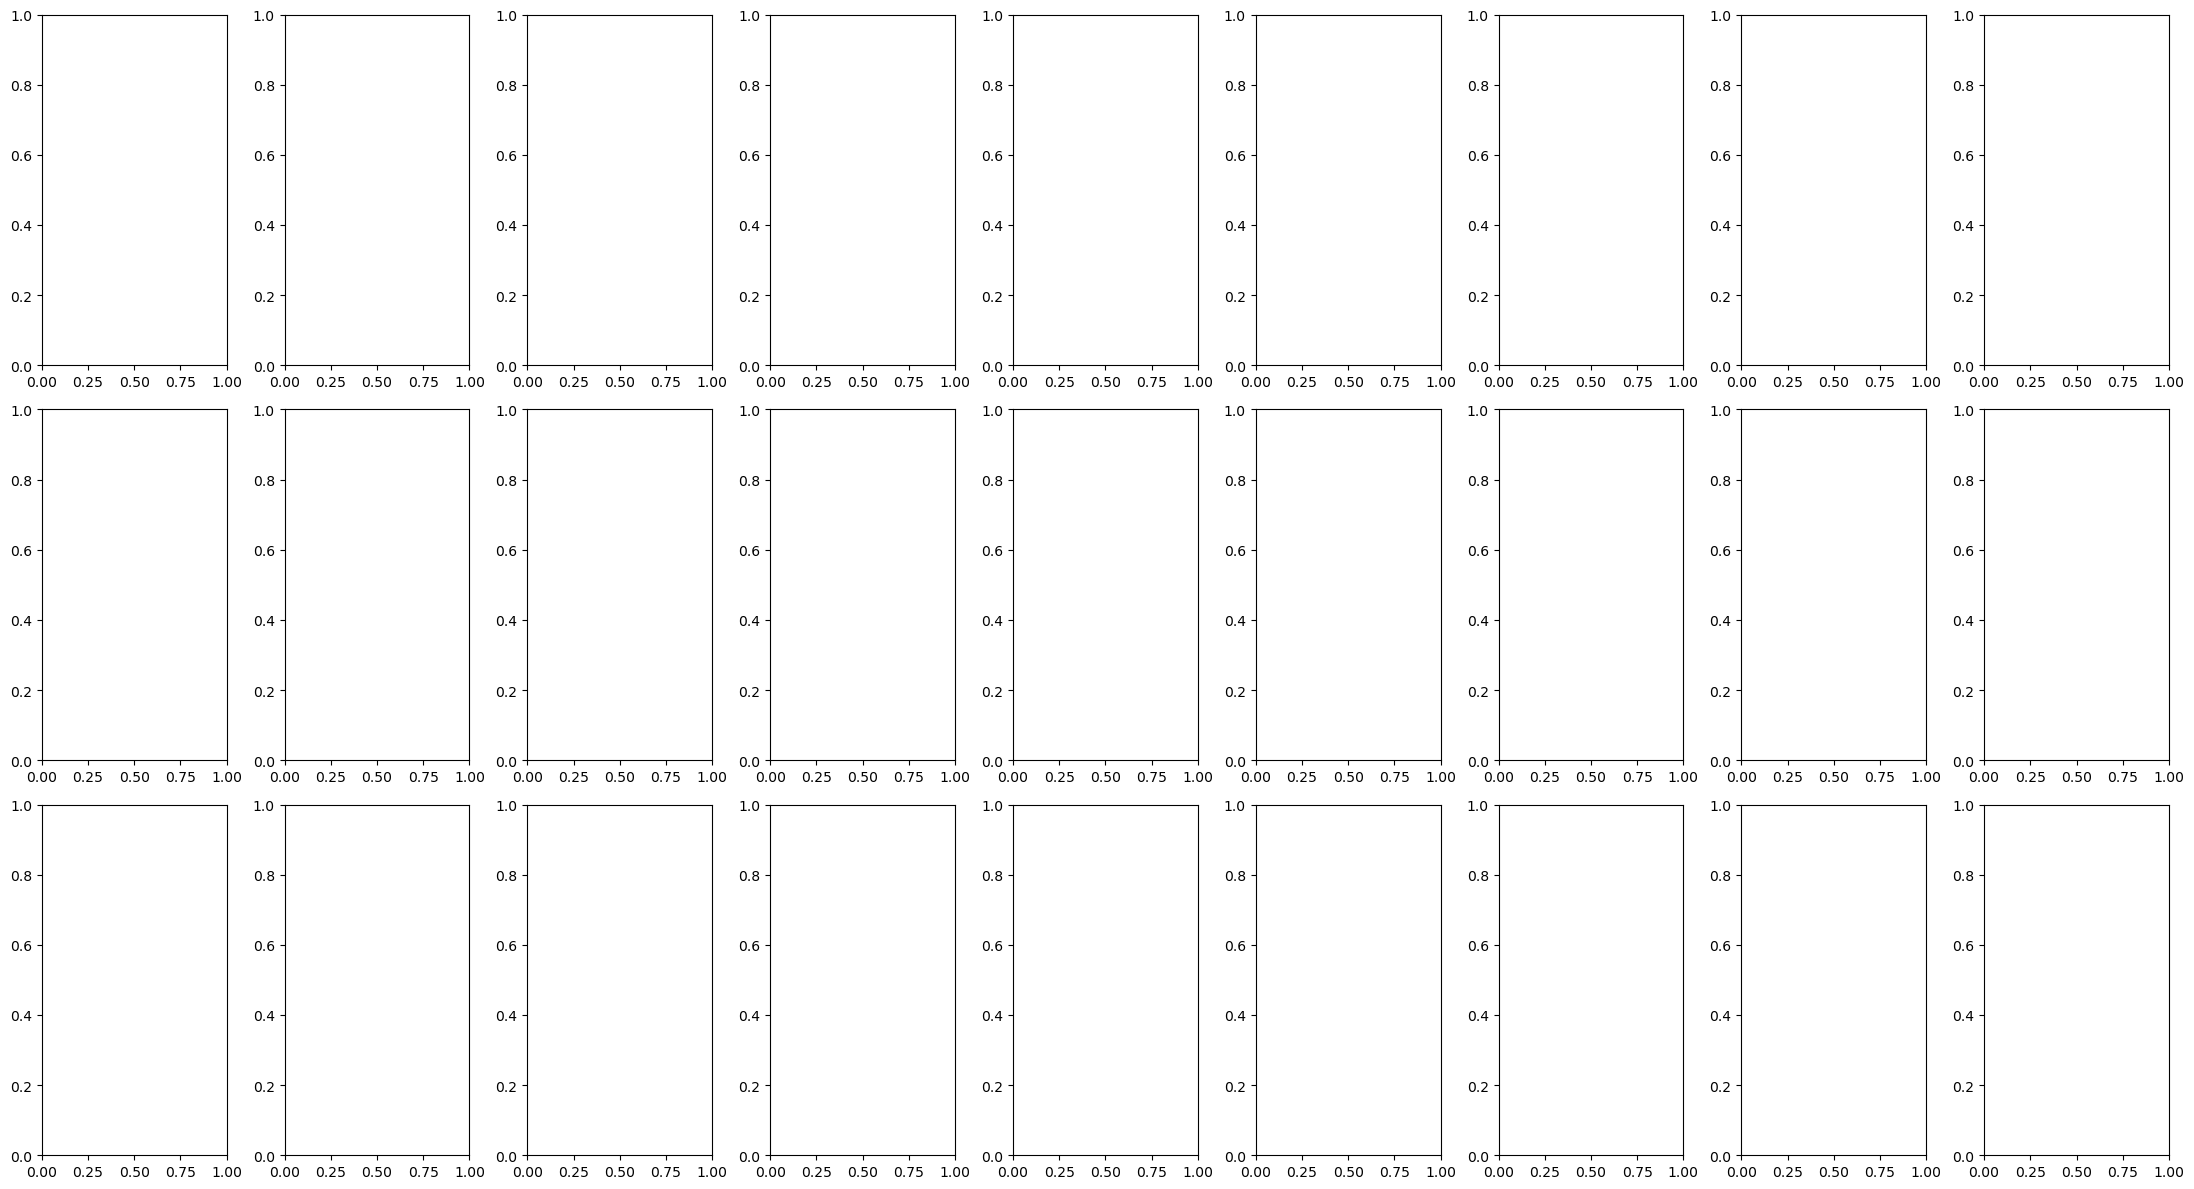

,geometry,S1_YEAR,THRESHOLD,FILENAME,DCA_ID
0,"POLYGON ((9565260 2885560, 9565260 2885540, 95...",2017,-2.78,EQUI7_NA020M_E093N027T3_rqatrend_VH_A_thresh_3...,bark_beetle
1,"POLYGON ((9564760 2885440, 9564760 2885420, 95...",2017,-2.78,EQUI7_NA020M_E093N027T3_rqatrend_VH_A_thresh_3...,bark_beetle
2,"POLYGON ((9565160 2885400, 9565160 2885380, 95...",2017,-2.78,EQUI7_NA020M_E093N027T3_rqatrend_VH_A_thresh_3...,bark_beetle
3,"POLYGON ((9565020 2885400, 9565020 2885380, 95...",2017,-2.78,EQUI7_NA020M_E093N027T3_rqatrend_VH_A_thresh_3...,bark_beetle
4,"POLYGON ((9565000 2885320, 9565000 2885300, 95...",2017,-2.78,EQUI7_NA020M_E093N027T3_rqatrend_VH_A_thresh_3...,bark_beetle
...,...,...,...,...,...
25715,"POLYGON ((8610040 2694400, 8610040 2694340, 86...",2020,0.72,EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3...,defoliators
25716,"POLYGON ((8609920 2694320, 8609920 2694300, 86...",2020,0.72,EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3...,defoliators
25717,"POLYGON ((8611000 2696100, 8611000 2695920, 86...",2020,0.72,EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3...,defoliators
25718,"POLYGON ((8608440 2696300, 8608440 2696040, 86...",2020,0.72,EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3...,defoliators


In [277]:
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray
import os
import re
import geopandas as gpd
import pandas as pd

# --- PARAMETERS ---
tcc_threshold = 0.3   # TCC threshold
center = -1.28
step = 0.5
thresholds = [center - 4*step, center - 3*step, center - 2*step, center - step, center, center + step, center + 2*step, center + 3*step, center + 4*step]
dca_ids = ["bark_beetle", "wind", "defoliators"]

processed = {}  # store masked DataArrays
all_polygons = []  # store extracted polygons

# --- LOOP OVER DCA_IDs ---
# --- LOOP OVER DCA_IDs ---
for dca_id in dca_ids:
    # --- FIND ALL ZARR FILES FOR THIS DCA_ID ---
    zarr_files = [
        os.path.join(targetfolder, f)
        for f in os.listdir(targetfolder)
        if f.endswith(".zarr") and f"subset_{dca_id}" in f
    ]
    if not zarr_files:
        print(f"No files found for {dca_id}")
        continue

    print(f"Found {len(zarr_files)} Zarr files for {dca_id}")

    # --- PROCESS EACH FILE TO EXTRACT POLYGONS ---
    all_polygons = []
    for path in zarr_files:
        da = xr.open_zarr(path, consolidated=False)["layer"]
        da = da.rio.set_spatial_dims("X", "Y", inplace=False)
        da = da.rio.write_crs("EPSG:27705")

        # Apply thresholds & TCC mask (loop thresholds if needed)
        for t in thresholds:
            da_thresh = (da > t).astype(int)
            da_thresh = da_thresh.rio.set_spatial_dims("X", "Y", inplace=False)
            da_thresh = da_thresh.rio.write_crs("EPSG:27705")

            if tcc_path is not None:
                mask = apply_tcc_mask(da_thresh, tcc_path, threshold=tcc_threshold)
                da_final = mask.astype(int)
            else:
                da_final = da_thresh.astype(int)

            # Extract polygons within buffer
            bb_row = ids[ids["DCA_ID"] == dca_id].iloc[0]
            buffer_gdf = gpd.GeoDataFrame(geometry=[bb_row.geometry.buffer(500)], crs=ids.crs)
            polys = extract_polygons_within_buffer(da_final, buffer_gdf, filename=os.path.basename(path), threshold=t)
            polys['DCA_ID'] = dca_id
            polys['THRESHOLD'] = t
            all_polygons.append(polys)

    # --- MERGE ALL POLYGONS FOR THIS DCA_ID ---
    if all_polygons:
        merged_polygons_dca = pd.concat(all_polygons, ignore_index=True)
        # store or append to global list
        final_gdf = pd.concat([final_gdf, merged_polygons_dca], ignore_index=True) if 'final_gdf' in globals() else merged_polygons_dca

    # --- OPTIONAL: pick one representative Zarr for plotting only ---
    representative_path = zarr_files[0]
    print(f"Using {representative_path} for plots for {dca_id}")

# --- PLOT EVERYTHING ---
fig, axes = plt.subplots(len(dca_ids), len(thresholds), figsize=(22, 4*len(dca_ids)))

if len(dca_ids) == 1:
    axes = [axes]

for i, dca_id in enumerate(dca_ids):
    if dca_id not in processed:
        continue

    bb = ids[ids["DCA_ID"] == dca_id]
    bb_row = bb.iloc[0]
    row_label = dca_id.replace("_", " ").upper()
    buffer_gdf = gpd.GeoDataFrame(geometry=[bb_row.geometry.buffer(500)], crs=ids.crs)

    for j, da_final in enumerate(processed[dca_id]):
        ax = axes[i, j]

        # Plot masked, thresholded disturbance
        da_final.plot.imshow(ax=ax, add_colorbar=False, cmap="gray", vmin=0, vmax=1)

        # Overlay original polygon (red) and buffer (blue)
        bb.boundary.plot(ax=ax, edgecolor="red", linewidth=1.5)
        buffer_gdf.boundary.plot(ax=ax, edgecolor="blue", linewidth=1.5)

        # Column titles
        if i == 0:
            ax.set_title(f"> {thresholds[j]:.2f}", fontweight="bold", fontsize=12)
        else:
            ax.set_title(" ", fontweight="bold", fontsize=12)

        # Row labels
        if j == 0:
            ax.set_ylabel(row_label, rotation=90, fontweight="bold", fontsize=12,
                          labelpad=20, va="center")

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# --- final_gdf now contains all polygons intersecting the buffer with metadata ---
final_gdf

In [278]:
# Ensure threshold column exists
if 'THRESHOLD' not in final_gdf.columns:
    final_gdf['THRESHOLD'] = final_gdf['THRESHOLD']  # adjust if your column name differs

# --- MERGE POLYGONS BY DCA_ID AND THRESHOLD ---
merged_gdf = final_gdf.dissolve(by=['DCA_ID', 'THRESHOLD'], as_index=False)

# Reset index and keep only geometry + metadata
merged_gdf = merged_gdf[['DCA_ID', 'THRESHOLD', 'geometry']]

print("Merged polygons per DCA_ID and threshold:")
merged_gdf


Merged polygons per DCA_ID and threshold:


,DCA_ID,THRESHOLD,geometry
0,bark_beetle,-3.28,"MULTIPOLYGON (((9564740 2884660, 9564720 28846..."
1,bark_beetle,-2.78,"MULTIPOLYGON (((9564840 2884560, 9564820 28845..."
2,bark_beetle,-2.28,"MULTIPOLYGON (((9564720 2884660, 9564720 28846..."
3,bark_beetle,-1.78,"MULTIPOLYGON (((9564720 2884640, 9564720 28846..."
4,bark_beetle,-1.28,"MULTIPOLYGON (((9564720 2884680, 9564740 28846..."
5,bark_beetle,-0.78,"MULTIPOLYGON (((9564820 2884640, 9564820 28846..."
6,bark_beetle,-0.28,"MULTIPOLYGON (((9564760 2884720, 9564760 28847..."
7,bark_beetle,0.22,"MULTIPOLYGON (((9564620 2884680, 9564620 28847..."
8,bark_beetle,0.72,"MULTIPOLYGON (((9564120 2885640, 9564100 28856..."
9,defoliators,-3.28,"MULTIPOLYGON (((8609380 2694420, 8609360 26944..."


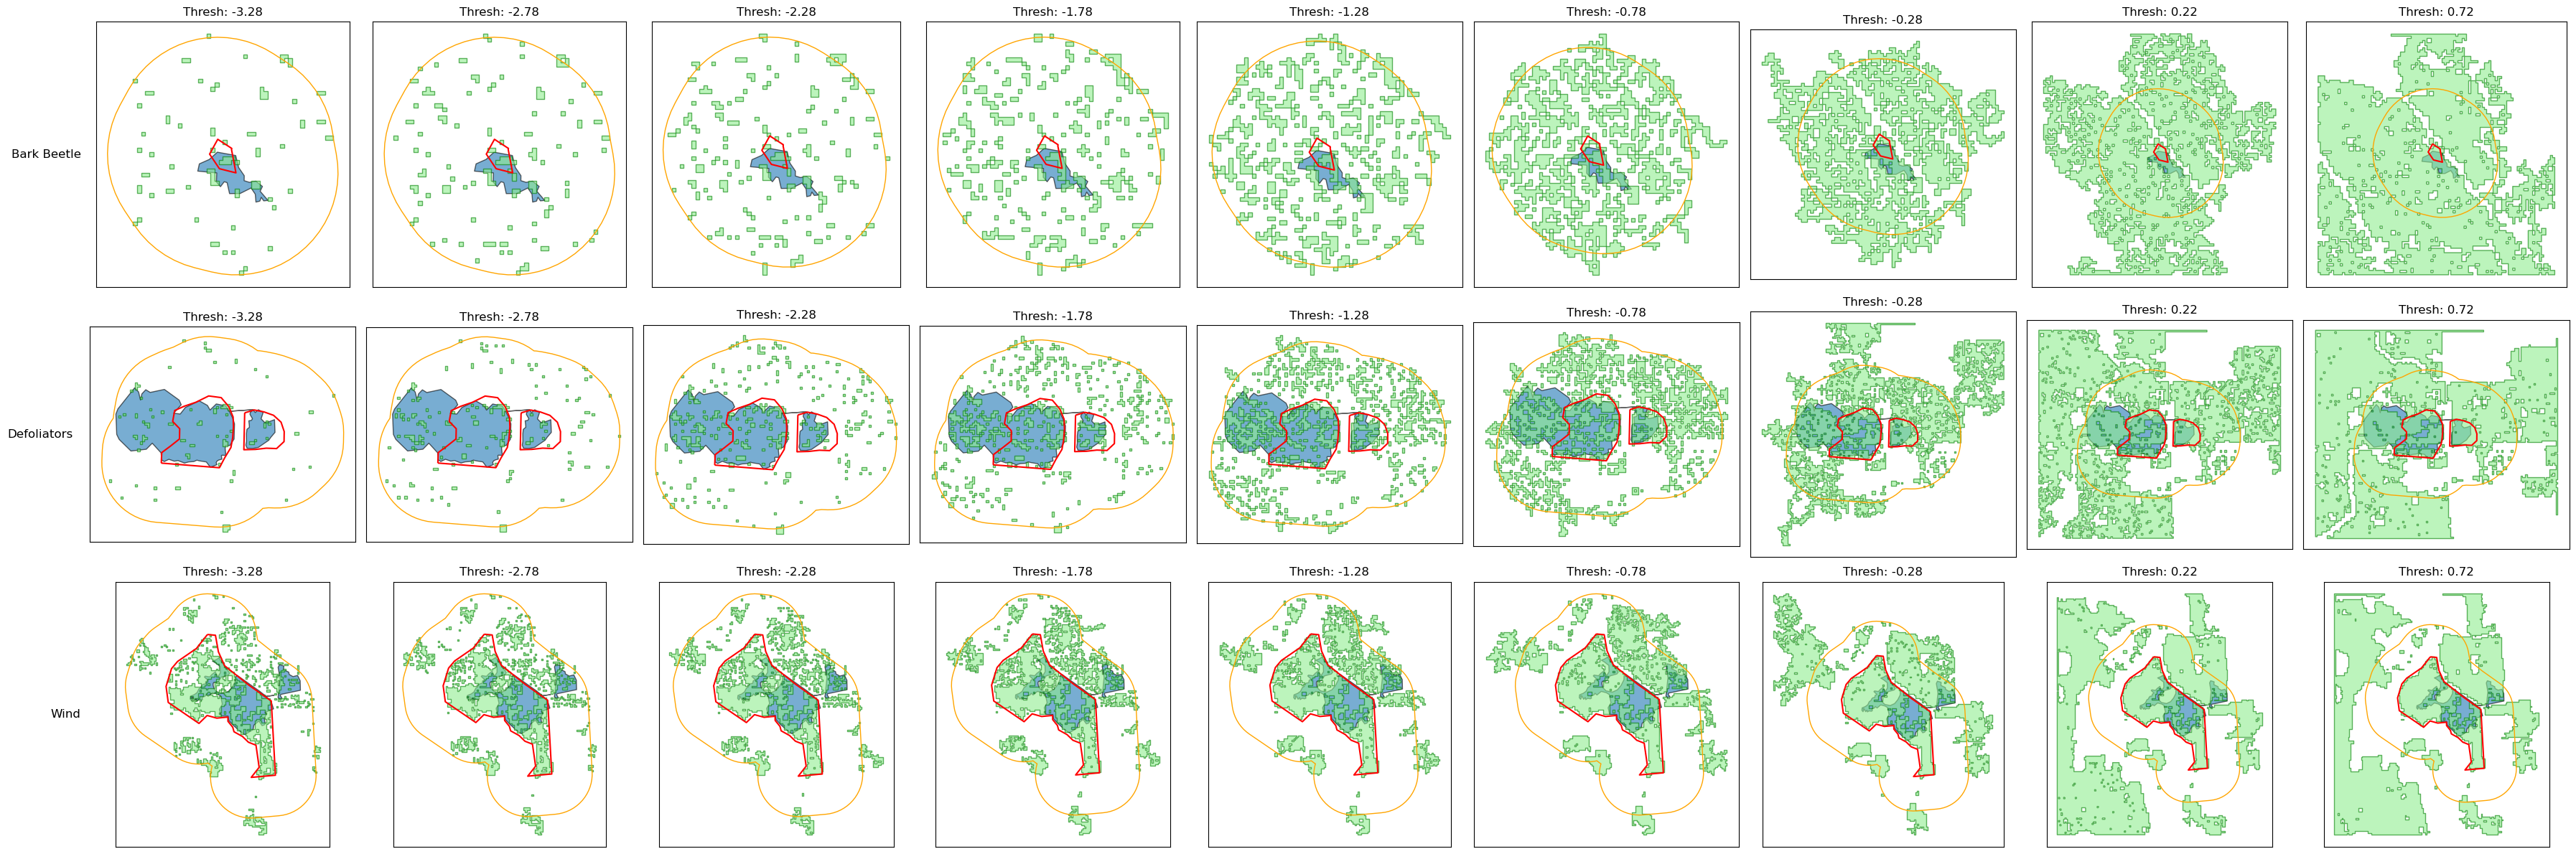

In [279]:
import matplotlib.pyplot as plt
import geopandas as gpd
manual_dict = {
    "bark_beetle": manual_bark_beetle_elem,
    "wind": manual_wind_elem,
    "defoliators": manual_defoliators_elem
}
# --- Parameters ---
dca_ids = merged_gdf['DCA_ID'].unique()
thresholds = sorted(merged_gdf['THRESHOLD'].unique())

fig, axes = plt.subplots(len(dca_ids), len(thresholds), figsize=(4*len(thresholds), 4*len(dca_ids)))

# If only one row or column, make axes 2D array-like
if len(dca_ids) == 1:
    axes = axes[np.newaxis, :]
if len(thresholds) == 1:
    axes = axes[:, np.newaxis]

for i, dca_id in enumerate(dca_ids):
    manual_bb = manual_dict[dca_id].to_crs(merged_gdf.crs)
    
    for j, thresh in enumerate(thresholds):
        ax = axes[i, j]
        
        # Select merged polygons for this DCA_ID and threshold
        plot_gdf = merged_gdf[(merged_gdf['DCA_ID'] == dca_id) & 
                               (merged_gdf['THRESHOLD'] == thresh)].copy()
        plot_gdf = plot_gdf.to_crs(merged_gdf.crs)
        
        # --- Plot ---
        manual_bb.plot(ax=ax, edgecolor="black", alpha=0.6, label="Manual")
        plot_gdf.plot(ax=ax, color="lightgreen", edgecolor="green", alpha=0.6, label="Merged")
        
        # Original DCA polygon
        bb = ids[ids["DCA_ID"] == dca_id]
        bb.boundary.plot(ax=ax, edgecolor="red", linewidth=1.5, label="Original DCA polygon")
        
        # Buffer 500 m
        bb.buffer(500).boundary.plot(ax=ax, edgecolor="orange", linewidth=1, label="Buffer")
        
        ax.set_title(f"Thresh: {thresh:.2f}")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")
        
        if j == 0:
            ax.set_ylabel(dca_id.replace("_"," ").title(), fontsize=12, rotation=0, labelpad=50, va="center")

plt.tight_layout()
plt.show()


/tmp/ipykernel_634006/1585017297.py:23: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  manual_union = manual_gdf.unary_union  # union of all manual polygons
/tmp/ipykernel_634006/1585017297.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_union = merged_thresh_gdf.unary_union
/tmp/ipykernel_634006/1585017297.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_union = merged_thresh_gdf.unary_union
/tmp/ipykernel_634006/1585017297.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_union = merged_thresh_gdf.unary_union
/tmp/ipykernel_634006/1585017297.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_union = merged_thresh_gdf.unary_union
/tmp/ipykernel_634006/1585017297.py

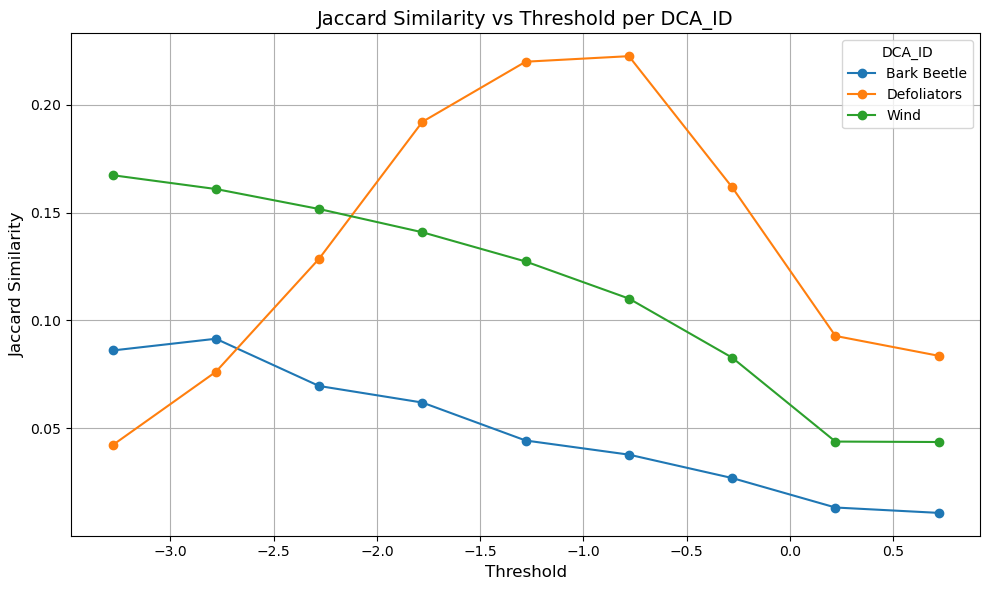

In [280]:
import pandas as pd

# Map manual DCA_IDs to GeoDataFrames
manual_dict = {
    "bark_beetle": manual_bark_beetle_elem,
    "wind": manual_wind_elem,
    "defoliators": manual_defoliators_elem
}

# Ensure all manual GeoDataFrames are in the same CRS as merged_gdf
for key in manual_dict:
    manual_dict[key] = manual_dict[key].to_crs(merged_gdf.crs)

# Prepare a list to store results
jaccard_results = []

# Loop over each DCA_ID
for dca_id in merged_gdf['DCA_ID'].unique():
    manual_gdf = manual_dict.get(dca_id)
    if manual_gdf is None or manual_gdf.empty:
        continue  # skip if no manual polygons
    
    manual_union = manual_gdf.unary_union  # union of all manual polygons

    # Loop over thresholds for this DCA_ID
    merged_subset = merged_gdf[merged_gdf['DCA_ID'] == dca_id]
    for thresh in merged_subset['THRESHOLD'].unique():
        merged_thresh_gdf = merged_subset[merged_subset['THRESHOLD'] == thresh]
        merged_union = merged_thresh_gdf.unary_union

        # Compute intersection and union
        intersection = manual_union.intersection(merged_union)
        union = manual_union.union(merged_union)

        # Jaccard index
        jaccard_index = intersection.area / union.area if not union.is_empty else 0.0

        # Store results
        jaccard_results.append({
            "DCA_ID": dca_id,
            "threshold": thresh,
            "jaccard_index": jaccard_index
        })

# Convert results to DataFrame
jaccard_df = pd.DataFrame(jaccard_results)

# Sort for readability
jaccard_df = jaccard_df.sort_values(by=["DCA_ID", "threshold"])
jaccard_df

import matplotlib.pyplot as plt

# --- Plot Jaccard similarity per DCA_ID ---
fig, ax = plt.subplots(figsize=(10, 6))

for dca_id in jaccard_df['DCA_ID'].unique():
    subset = jaccard_df[jaccard_df['DCA_ID'] == dca_id]
    ax.plot(
        subset['threshold'],
        subset['jaccard_index'],
        marker='o',
        label=dca_id.replace("_", " ").title()
    )

ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Jaccard Similarity", fontsize=12)
ax.set_title("Jaccard Similarity vs Threshold per DCA_ID", fontsize=14)
ax.legend(title="DCA_ID")
ax.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_634006/808149434.py:23: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  manual_union = manual_gdf.unary_union  # union of all manual polygons
/tmp/ipykernel_634006/808149434.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_union = merged_thresh_gdf.unary_union
/tmp/ipykernel_634006/808149434.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_union = merged_thresh_gdf.unary_union
/tmp/ipykernel_634006/808149434.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_union = merged_thresh_gdf.unary_union
/tmp/ipykernel_634006/808149434.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_union = merged_thresh_gdf.unary_union
/tmp/ipykernel_634006/808149434.py:29: D

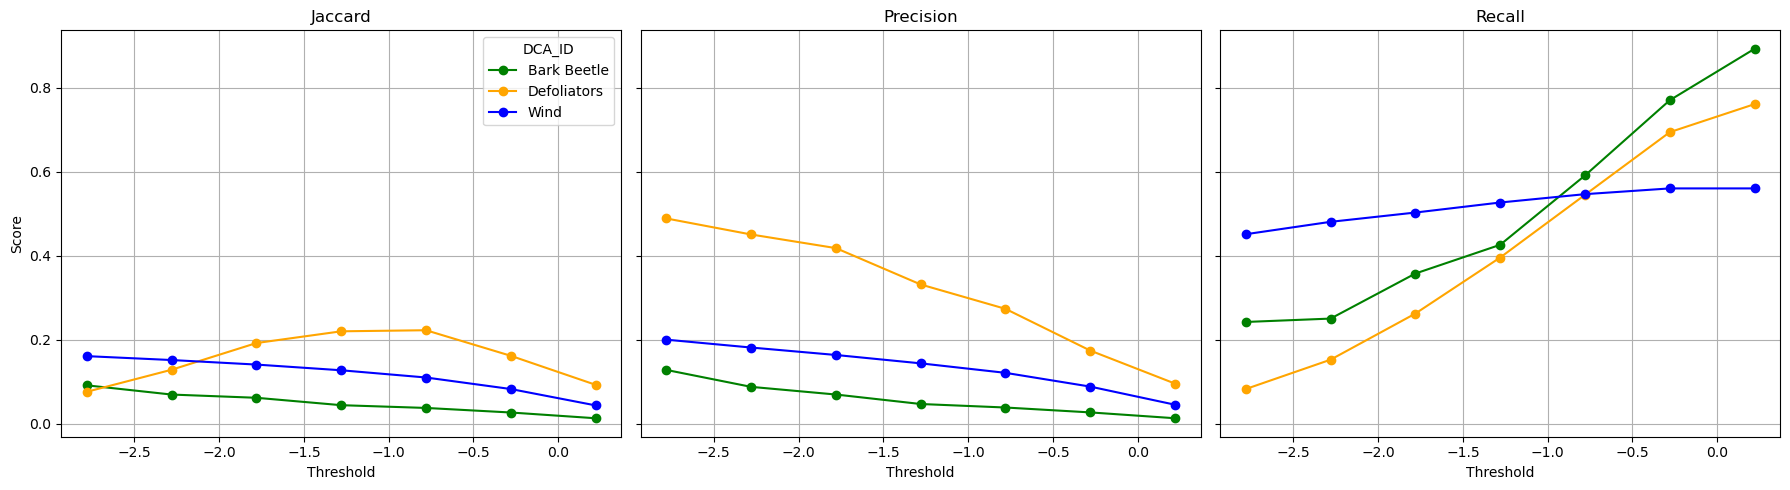

In [273]:
import pandas as pd
import matplotlib.pyplot as plt

# Map manual DCA_IDs to GeoDataFrames
manual_dict = {
    "bark_beetle": manual_bark_beetle_elem,
    "wind": manual_wind_elem,
    "defoliators": manual_defoliators_elem
}
# Ensure all manual GeoDataFrames are in the same CRS as merged_gdf
for key in manual_dict:
    manual_dict[key] = manual_dict[key].to_crs(merged_gdf.crs)

# Store results
metrics_results = []

# Loop over each DCA_ID
for dca_id in merged_gdf['DCA_ID'].unique():
    manual_gdf = manual_dict.get(dca_id)
    if manual_gdf is None or manual_gdf.empty:
        continue  # skip if no manual polygons
    
    manual_union = manual_gdf.unary_union  # union of all manual polygons

    # Loop over thresholds for this DCA_ID
    merged_subset = merged_gdf[merged_gdf['DCA_ID'] == dca_id]
    for thresh in merged_subset['THRESHOLD'].unique():
        merged_thresh_gdf = merged_subset[merged_subset['THRESHOLD'] == thresh]
        merged_union = merged_thresh_gdf.unary_union

        # Compute intersection and union
        intersection = manual_union.intersection(merged_union)
        union = manual_union.union(merged_union)

        # --- Metrics ---
        jaccard_index = intersection.area / union.area if not union.is_empty else 0.0
        precision = intersection.area / merged_union.area if not merged_union.is_empty else 0.0
        recall = intersection.area / manual_union.area if not manual_union.is_empty else 0.0

        metrics_results.append({
            "DCA_ID": dca_id,
            "threshold": thresh,
            "Jaccard": jaccard_index,
            "Precision": precision,
            "Recall": recall
        })

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_results)
metrics_df = metrics_df.sort_values(by=["DCA_ID", "threshold"])

# --- Plot metrics in 3 subplots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

metrics = ["Jaccard", "Precision", "Recall"]
colors = {"bark_beetle": "green", "wind": "blue", "defoliators": "orange"}

for ax, metric in zip(axes, metrics):
    for dca_id in metrics_df['DCA_ID'].unique():
        subset = metrics_df[metrics_df['DCA_ID'] == dca_id]
        ax.plot(subset['threshold'], subset[metric], marker='o', color=colors[dca_id], label=dca_id.replace("_", " ").title())
    ax.set_xlabel("Threshold")
    ax.set_title(metric)
    ax.grid(True)

axes[0].set_ylabel("Score")
axes[0].legend(title="DCA_ID")
plt.tight_layout()
plt.show()


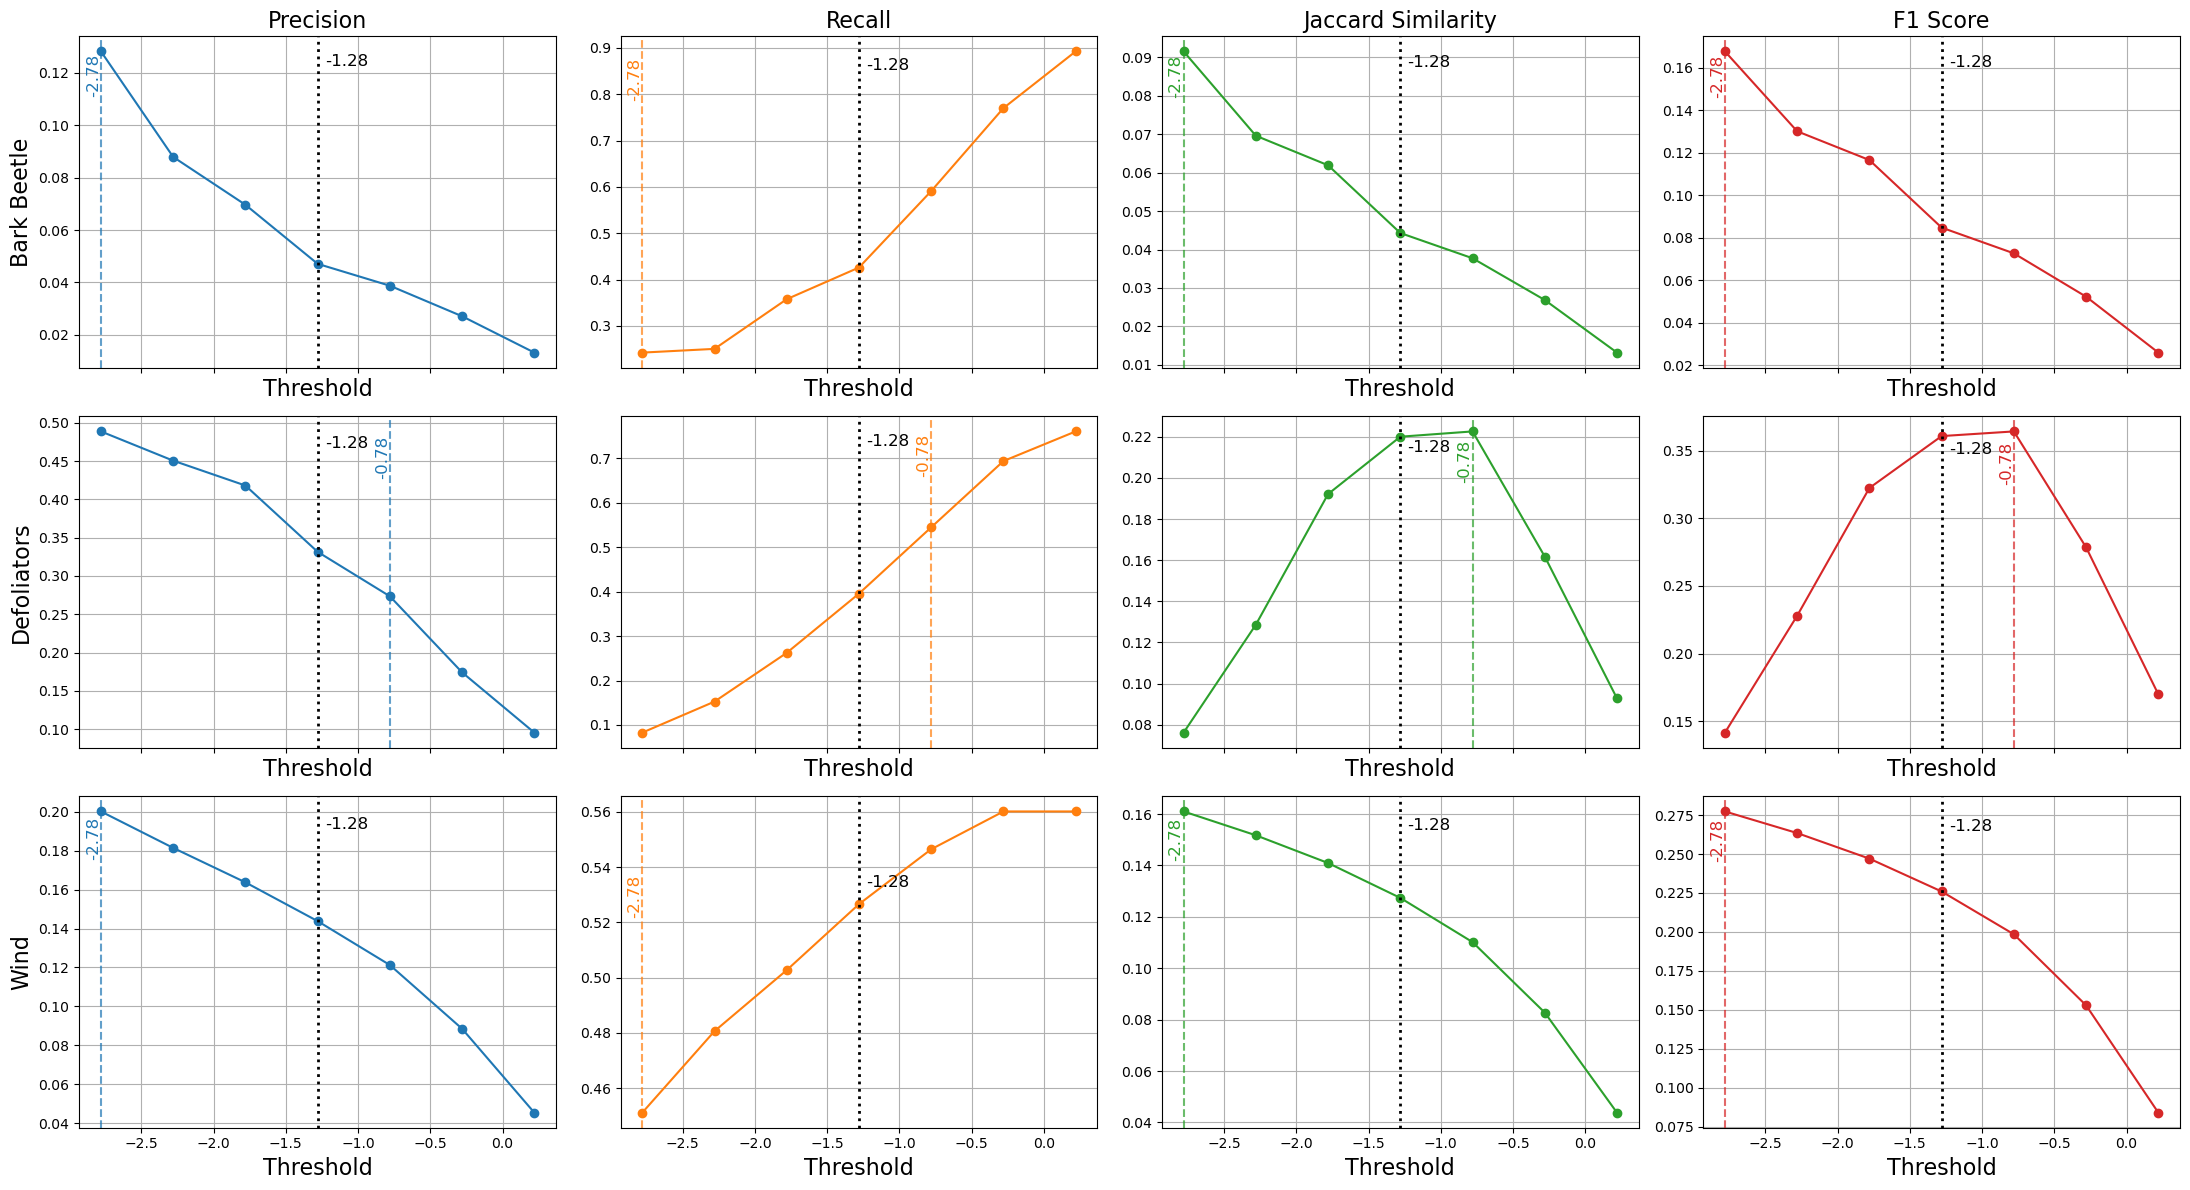

Best thresholds per DCA_ID:
             threshold        F1
DCA_ID                          
bark_beetle      -2.78  0.167680
defoliators      -0.78  0.364201
wind             -2.78  0.277337


In [274]:
import matplotlib.pyplot as plt

# Compute F1 if not already done
metrics_df['F1'] = 2 * (metrics_df['Precision'] * metrics_df['Recall']) / (metrics_df['Precision'] + metrics_df['Recall'])

# Find the happy threshold (F1-maximizing) per DCA_ID
best_thresholds = metrics_df.loc[metrics_df.groupby('DCA_ID')['F1'].idxmax(), ['DCA_ID', 'threshold', 'F1']]
best_thresholds = best_thresholds.set_index('DCA_ID')

metrics = ['Precision', 'Recall', 'Jaccard', 'F1']
y_labels = ['Precision', 'Recall', 'Jaccard Similarity', 'F1 Score']

# --- Plot one row per DCA_ID, 4 columns (metrics) ---
fig, axes = plt.subplots(len(metrics_df['DCA_ID'].unique()), len(metrics), figsize=(22, 4*len(metrics_df['DCA_ID'].unique())), sharex=True)

if len(metrics_df['DCA_ID'].unique()) == 1:
    axes = axes[np.newaxis, :]  # ensure 2D array

medium_threshold = -1.28  # chosen medium threshold

for i, dca_id in enumerate(metrics_df['DCA_ID'].unique()):
    subset = metrics_df[metrics_df['DCA_ID'] == dca_id]
    happy_thresh = best_thresholds.loc[dca_id, 'threshold']
    
    for j, (metric, y_label) in enumerate(zip(metrics, y_labels)):
        ax = axes[i, j]
        
        # Plot metric curve
        ax.plot(subset['threshold'], subset[metric], marker='o', label=dca_id.replace("_", " ").title(), color=f"C{j}")
        
        # Plot happy threshold line, same color as curve
        ax.axvline(happy_thresh, color=f"C{j}", linestyle='--', alpha=0.7)
        ax.text(happy_thresh, ax.get_ylim()[1]*0.95, f'{happy_thresh:.2f}', rotation=90, va='top', ha='right', fontsize=12, color=f"C{j}")
        
        # --- Plot medium threshold line in black ---
        ax.axvline(medium_threshold, color='black', linestyle=':', linewidth=2)
        ax.text(medium_threshold +0.05, ax.get_ylim()[1]*0.95, f'{medium_threshold:.2f}', rotation=0, va='top', ha='left', fontsize=12, color='black')
        
        if i == 0:
            ax.set_title(y_label, fontsize=16)
        if j == 0:
            ax.set_ylabel(dca_id.replace("_"," ").title(), fontsize=16)
        ax.set_xlabel("Threshold", fontsize=16)    
        ax.grid(True)

plt.tight_layout()
plt.show()
print("Best thresholds per DCA_ID:")
print(best_thresholds)


Middle-ground threshold (F1-maximizing): -1.78
Middle-ground threshold (all metrics balanced): -1.78


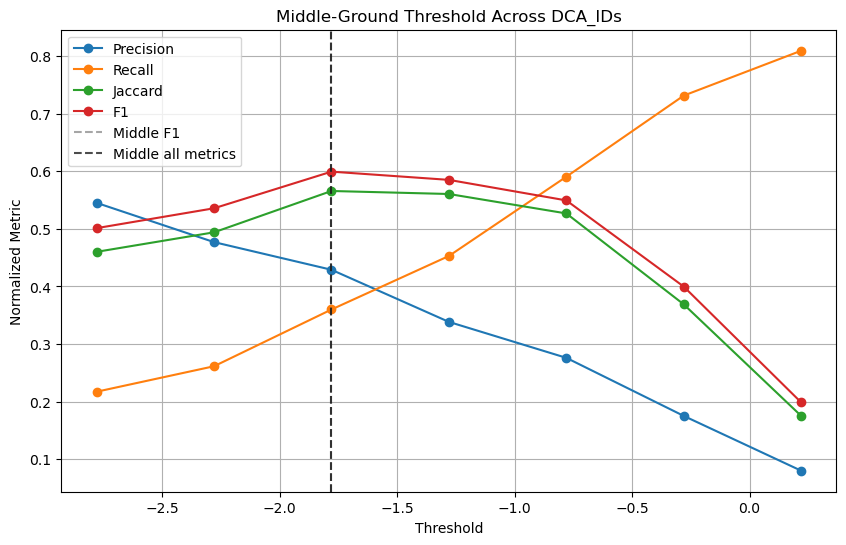

In [275]:
import numpy as np

# Create a copy to avoid modifying original
metrics_norm = metrics_df.copy()

# Optional: normalize each metric across all DCA_IDs and thresholds
for metric in metrics:
    min_val = metrics_norm[metric].min()
    max_val = metrics_norm[metric].max()
    metrics_norm[metric + "_norm"] = (metrics_norm[metric] - min_val) / (max_val - min_val + 1e-8)

# Compute mean normalized metrics per threshold
mean_metrics = metrics_norm.groupby('threshold')[[m+"_norm" for m in metrics]].mean().reset_index()

# Option 1: max average F1
happy_thresh_f1 = mean_metrics.loc[mean_metrics['F1_norm'].idxmax(), 'threshold']

# Option 2: max sum of all normalized metrics (balances Precision, Recall, Jaccard, F1)
mean_metrics['sum_norm'] = mean_metrics[[m+"_norm" for m in metrics]].sum(axis=1)
happy_thresh_sum = mean_metrics.loc[mean_metrics['sum_norm'].idxmax(), 'threshold']

print(f"Middle-ground threshold (F1-maximizing): {happy_thresh_f1:.2f}")
print(f"Middle-ground threshold (all metrics balanced): {happy_thresh_sum:.2f}")

fig, ax = plt.subplots(figsize=(10,6))

for metric in metrics:
    ax.plot(mean_metrics['threshold'], mean_metrics[metric+"_norm"], marker='o', label=metric)

# Mark middle-ground thresholds
ax.axvline(happy_thresh_f1, color='gray', linestyle='--', alpha=0.7, label='Middle F1')
ax.axvline(happy_thresh_sum, color='black', linestyle='--', alpha=0.7, label='Middle all metrics')

ax.set_xlabel("Threshold")
ax.set_ylabel("Normalized Metric")
ax.set_title("Middle-Ground Threshold Across DCA_IDs")
ax.legend()
ax.grid(True)
plt.show()


In [276]:
import pandas as pd

# Compute max per metric across all DCA_IDs
metric_max = metrics_df.groupby('DCA_ID')[metrics].max().reset_index()

# Define fraction of maximum to consider (e.g., 90%)
fraction = 0.9

# Dictionary to store threshold ranges
threshold_ranges = {}

for metric in metrics:
    ranges = []
    for dca_id in metrics_df['DCA_ID'].unique():
        subset = metrics_df[metrics_df['DCA_ID'] == dca_id]
        max_val = subset[metric].max()
        # Select thresholds achieving >= fraction of max
        good_thresh = subset[subset[metric] >= fraction*max_val]['threshold']
        if not good_thresh.empty:
            ranges.append((good_thresh.min(), good_thresh.max()))
    # Overall range across all DCA_IDs
    overall_min = min([r[0] for r in ranges])
    overall_max = max([r[1] for r in ranges])
    threshold_ranges[metric] = (overall_min, overall_max)

threshold_ranges


{'Precision': (-2.7800000000000002, -2.2800000000000002),
 'Recall': (-1.28, 0.21999999999999997),
 'Jaccard': (-2.7800000000000002, -0.78),
 'F1': (-2.7800000000000002, -0.78)}